# Project 3: Trapped in a Low Dimension
## Exploring Neural Population Dynamics through Dimensionality Reduction
### MICrONS Dataset — Mouse Visual Cortex (V1)

**Course:** Neuroscience Computation  
**Dataset:** MICrONS Functional + Structural Connectomics (version 1718)  
**Session analysed:** `9_4`

---

## 1. Introduction

The visual cortex encodes sensory information through the coordinated activity
of thousands of neurons.  Each neuron contributes one dimension to the population
state, so the space of possible activity patterns is extremely high-dimensional.
A central hypothesis in systems neuroscience — the **neural manifold hypothesis**
— posits that, despite this high dimensionality, the brain actually operates on
a much lower-dimensional surface, because neural activity is strongly structured
by the statistics of natural inputs and by the architecture of the circuit.

This project exploits the **MICrONS** dataset, which pairs two-photon calcium
imaging of tens of thousands of V1 neurons in a live mouse with a millimetre-scale
electron-microscopy reconstruction of the same tissue.  The functional recording
covers several types of visual stimuli (parametric patterns, natural movie clips),
giving us rich coverage of the neural response space.

We apply **PCA**, **t-SNE**, **UMAP**, and (optionally) **CEBRA** to the
population response matrix and ask:

* Does the neural population trace out a low-dimensional manifold?
* Can different stimulus types be distinguished from the geometry of that manifold?
* Do different algorithms agree on the structure they reveal?
* Do temporally adjacent movie frames sit nearby in the embedding?

These questions connect directly to course material on population codes,
representational geometry, and the structure of sensory cortex.

## 2. Research Questions

1. **Stimulus discriminability** — Can the type of visual stimulus being shown
   be decoded from the low-dimensional representation of population activity?
   If so, stimulus identity is encoded in the *geometry* of the neural manifold.

2. **Algorithm agreement** — Do PCA, t-SNE, and UMAP converge on the same
   structure?  PCA captures linear variance; the nonlinear methods may reveal
   additional structure.  Agreement across methods argues for robustness.

3. **Intrinsic dimensionality** — How many principal components are needed to
   explain most of the population variance?  This constrains theories of neural
   coding and the complexity of the underlying computation.

4. **Temporal continuity** — For naturalistic movie clips, do temporally
   adjacent frames cluster nearby in the embedding?  This would suggest the
   manifold tracks visual dynamics smoothly.

## 3. Setup & Imports

In [1]:
# ── Standard libraries ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
import seaborn as sns
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# ── Dimensionality-reduction ─────────────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scipy.stats import ttest_ind, ttest_1samp, wilcoxon

# ── UMAP (umap-learn) ─────────────────────────────────────────────────────────
try:
    import umap
    UMAP_AVAILABLE = True
    print("UMAP        ✓  (umap-learn)")
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP        ✗  — install: pip install umap-learn")

# ── CEBRA (optional) ──────────────────────────────────────────────────────────
try:
    import cebra
    CEBRA_AVAILABLE = True
    print("CEBRA       ✓")
except ImportError:
    CEBRA_AVAILABLE = False
    print("CEBRA       ✗  — install: pip install cebra  (optional)")

# ── MICrONS tools ─────────────────────────────────────────────────────────────
%load_ext autoreload
%autoreload 2
import microns_datacleaner as mic
import microns_datacleaner.filters as fl

print("\nAll core imports successful ✓")

UMAP        ✓  (umap-learn)


CEBRA       ✓



All core imports successful ✓


In [2]:
# ── Global plot style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 120,
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 12,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'legend.frameon'  : False,
    'savefig.bbox'    : 'tight',
})
SEED = 42

## 4. Data Loading

We follow the same pattern as the tutorial: use `MicronsDataCleaner` to
download the nucleus/segment metadata, then `MicronsFunctionalReader` for the
calcium-imaging traces.  We restrict to V1 neurons with clean axonal
proofreading and matched tuning data.

In [3]:
# ── Anatomical + functional metadata ────────────────────────────────────────
cleaner = mic.MicronsDataCleaner(datadir="data/", version=1718)
cleaner.download_nucleus_data()   # run once — writes CSVs to data/1718/raw/

units, segments = cleaner.process_nucleus_data(functional_data='best_only')
print(f"Total units loaded : {len(units)}")
print(f"Columns            : {list(units.columns)}")
units.head()

Transform positions:   0%|          | 0/94014 [00:00<?, ?it/s]

Transform positions:   7%|▋         | 6707/94014 [00:00<00:01, 67065.11it/s]

Transform positions:  14%|█▍        | 13414/94014 [00:00<00:01, 66744.81it/s]

Transform positions:  21%|██▏       | 20089/94014 [00:00<00:01, 66585.90it/s]

Transform positions:  28%|██▊       | 26780/94014 [00:00<00:01, 66709.29it/s]

...

Transform positions:  92%|█████████▏| 86939/94014 [00:01<00:00, 66858.48it/s]

Transform positions: 100%|█████████▉| 93635/94014 [00:01<00:00, 66885.62it/s]

Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 66671.71it/s]

Total units loaded : 90434
Columns            : ['nucleus_id', 'pt_root_id', 'pt_position_x', 'pt_position_y', 'pt_position_z', 'classification_system', 'cell_type', 'brain_area', 'strategy_axon', 'strategy_dendrite', 'session', 'scan_idx', 'unit_id', 'pref_ori', 'pref_dir', 'gOSI', 'gDSI', 'cc_abs', 'tuning_type', 'layer']


,nucleus_id,pt_root_id,pt_position_x,pt_position_y,pt_position_z,classification_system,cell_type,brain_area,strategy_axon,strategy_dendrite,session,scan_idx,unit_id,pref_ori,pref_dir,gOSI,gDSI,cc_abs,tuning_type,layer
0,373879,864691136090135607,828.189723,638.553801,783.72,excitatory_neuron,6P-CT,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
1,408486,864691135194387242,891.157407,662.693656,1002.96,nonneuron,oligo,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
2,199883,864691136041571414,514.440335,481.908658,1044.32,excitatory_neuron,5P-ET,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L5
3,200523,864691135777840480,513.635721,509.463386,652.56,excitatory_neuron,6P-CT,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
4,372649,864691136273924109,829.039163,557.615841,1039.92,excitatory_neuron,6P-IT,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6


In [4]:
# ── Filter to V1, proofread, matched tuning ─────────────────────────────────
v1_neurons = fl.filter_neurons(units, brain_area='V1',
                               proofread='ax_clean', tuning='matched')

v1_exc = v1_neurons[v1_neurons['classification_system'] == 'excitatory_neuron']
v1_inh = v1_neurons[v1_neurons['classification_system'] == 'inhibitory_neuron']

print(f"V1 neurons (proofread, matched): {len(v1_neurons)}")
print(f"  Excitatory : {len(v1_exc)}")
print(f"  Inhibitory : {len(v1_inh)}")
print()
print(v1_neurons['classification_system'].value_counts())

V1 neurons (proofread, matched): 728
  Excitatory : 728
  Inhibitory : 0

classification_system
excitatory_neuron    728
Name: count, dtype: int64


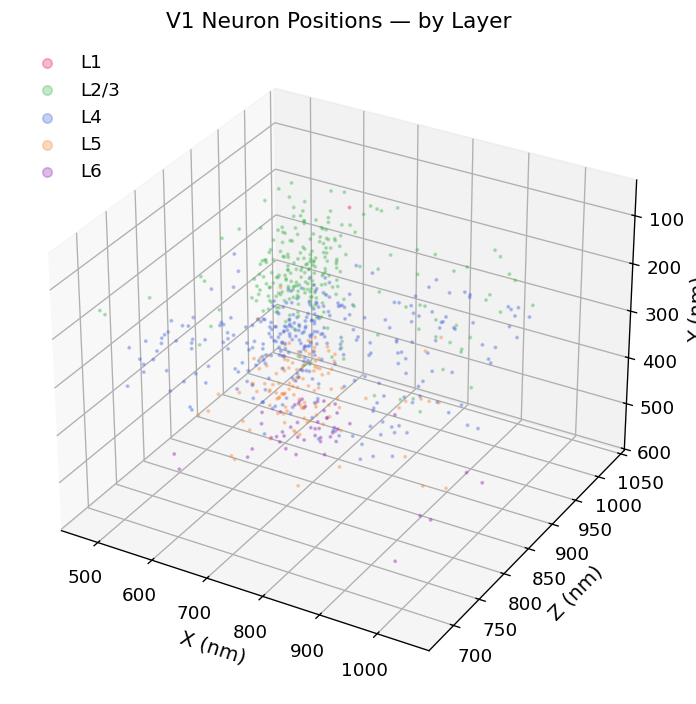

In [5]:
# ── 3-D spatial map of neurons by layer ─────────────────────────────────────
fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(projection='3d')
ax.zaxis.set_inverted(True)

LAYER_COLORS = {
    'L1'  : '#e6194b', 'L2/3': '#3cb44b',
    'L4'  : '#4363d8', 'L5'  : '#f58231', 'L6': '#911eb4'
}

for layer, color in LAYER_COLORS.items():
    ul = fl.filter_neurons(v1_neurons, layer=layer)
    if len(ul):
        ax.scatter(ul['pt_position_x'], ul['pt_position_z'], ul['pt_position_y'],
                   alpha=0.3, s=2, color=color, label=layer)

ax.set_xlabel('X (nm)'); ax.set_ylabel('Z (nm)'); ax.set_zlabel('Y (nm)')
ax.set_title('V1 Neuron Positions — by Layer')
ax.legend(markerscale=4, loc='upper left')
plt.tight_layout(); plt.show()

## 5. Building the Population Response Matrix

### Methodology

For each trial in session **9_4** we retrieve the response array
`r['responses']` of shape `(n_neurons, n_frames)`.  We average across frames
to obtain a single population response vector per trial, then group trials by
their stimulus hash (= unique visual stimulus) and average across repeated
presentations.

The result is a matrix **R** of shape `(n_unique_stimuli, n_neurons)`.  Each
row is a point in neuron-space; each column is one neuron's average response to
that stimulus.  This is the input to all dimensionality-reduction steps.

In [6]:
# ── Functional reader & trial inventory ─────────────────────────────────────
SESSION = "9_4"
funcreader = mic.MicronsFunctionalReader(path="microns.h5")
hashes = funcreader.get_hashes_by_session(SESSION)

stim_types = [funcreader.get_video_type(h) for h in hashes]
type_counts = Counter(stim_types)

print(f"Total trials in session {SESSION}: {len(hashes)}")
print("\nStimulus types:")
for k, v in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f"  {k:22s}: {v:4d} trials")

Total trials in session 9_4: 464

Stimulus types:
  Clip                  :  384 trials
  Monet2                :   40 trials
  Trippy                :   40 trials


In [7]:
# ── Collect per-trial mean responses ─────────────────────────────────────────
# hash_to_responses[h] = list of (n_neurons,) vectors, one per presentation
hash_to_responses = defaultdict(list)
hash_to_type      = {}

print("Loading trial responses ... (may take a few minutes)")
n_failed = 0

for trial_idx, h in enumerate(hashes):
    hash_to_type[h] = funcreader.get_video_type(h)
    try:
        r = funcreader.get_trial(SESSION, trial_idx)
        if r is None or 'responses' not in r:
            n_failed += 1
            continue
        # r['responses']: (n_neurons, n_frames)
        mean_resp = r['responses'].mean(axis=1)   # → (n_neurons,)
        hash_to_responses[h].append(mean_resp)
    except Exception:
        n_failed += 1

print(f"  Done.  {len(hash_to_responses)} unique stimuli loaded  |  {n_failed} trials skipped")

Loading trial responses ... (may take a few minutes)


  Done.  280 unique stimuli loaded  |  0 trials skipped


In [8]:
# ── Average across repeated presentations → final R matrix ──────────────────
unique_hashes = sorted(hash_to_responses.keys())
R_matrix  = np.array([np.mean(hash_to_responses[h], axis=0) for h in unique_hashes])
labels_raw = np.array([hash_to_type[h] for h in unique_hashes])

print(f"Response matrix shape : {R_matrix.shape}")
print(f"  rows = unique stimuli,  cols = neurons")
print()
print("Stimulus distribution in R:")
for lbl, cnt in Counter(labels_raw).items():
    print(f"  {lbl:22s}: {cnt}")

Response matrix shape : (280, 7855)
  rows = unique stimuli,  cols = neurons

Stimulus distribution in R:
  Trippy                : 20
  Clip                  : 240
  Monet2                : 20


## 6. Preprocessing

Before running dimensionality reduction we:

1. **Remove noisy neurons** — drop columns with >10 % NaN across stimuli.
2. **Impute remaining NaNs** — replace with the per-neuron mean.
3. **Remove silent stimuli** — drop rows with no variation (all-zero or constant).
4. **Z-score across stimuli** — subtract the mean and divide by the standard
   deviation of each neuron across stimuli.  This ensures that neurons with
   different baseline firing rates contribute equally.

In [9]:
# ── 1. Drop high-NaN neurons ─────────────────────────────────────────────────
nan_frac     = np.isnan(R_matrix).mean(axis=0)
keep_neurons = nan_frac < 0.10
R_clean      = R_matrix[:, keep_neurons].copy()
print(f"Neurons after NaN filter : {keep_neurons.sum()} / {R_matrix.shape[1]}")

# ── 2. Impute remaining NaNs ─────────────────────────────────────────────────
col_means = np.nanmean(R_clean, axis=0)
nan_idx   = np.where(np.isnan(R_clean))
R_clean[nan_idx] = np.take(col_means, nan_idx[1])

# ── 3. Drop near-silent stimuli ──────────────────────────────────────────────
active      = R_clean.std(axis=1) > 1e-6
R_clean     = R_clean[active]
labels      = labels_raw[active]
print(f"Stimuli after activity filter : {active.sum()} / {R_matrix.shape[0]}")

# ── 4. Z-score ───────────────────────────────────────────────────────────────
scaler   = StandardScaler()
R_scaled = scaler.fit_transform(R_clean)

print(f"\nFinal response matrix : {R_scaled.shape}")
print(f"  Mean : {R_scaled.mean():+.4f}  (should ≈ 0)")
print(f"  Std  : {R_scaled.std():+.4f}  (should ≈ 1)")

Neurons after NaN filter : 7855 / 7855
Stimuli after activity filter : 280 / 280

Final response matrix : (280, 7855)
  Mean : +0.0000  (should ≈ 0)
  Std  : +1.0000  (should ≈ 1)


In [10]:
# ── Colour coding for stimulus types ─────────────────────────────────────────
unique_labels  = sorted(set(labels))
n_types        = len(unique_labels)
palette        = plt.cm.get_cmap('tab10', n_types)
label_to_color = {lbl: palette(i) for i, lbl in enumerate(unique_labels)}
label_to_idx   = {lbl: i          for i, lbl in enumerate(unique_labels)}

le             = LabelEncoder()
y              = le.fit_transform(labels)
chance_level   = 1.0 / n_types

legend_patches = [Patch(color=label_to_color[l], label=l) for l in unique_labels]

print(f"Stimulus types in analysis ({n_types}):")
for lbl in unique_labels:
    print(f"  {lbl}  (n={np.sum(labels==lbl)})")
print(f"\nChance level for classifier : {chance_level:.3f}")

Stimulus types in analysis (3):
  Clip  (n=240)
  Monet2  (n=20)
  Trippy  (n=20)

Chance level for classifier : 0.333


## 7. Dimensionality Reduction

### 7a. Principal Component Analysis (PCA)

PCA finds the linear subspace that captures the most variance.  The *scree
plot* reveals the intrinsic dimensionality of the data; projecting onto the
first two or three PCs gives a linear view of stimulus separability.

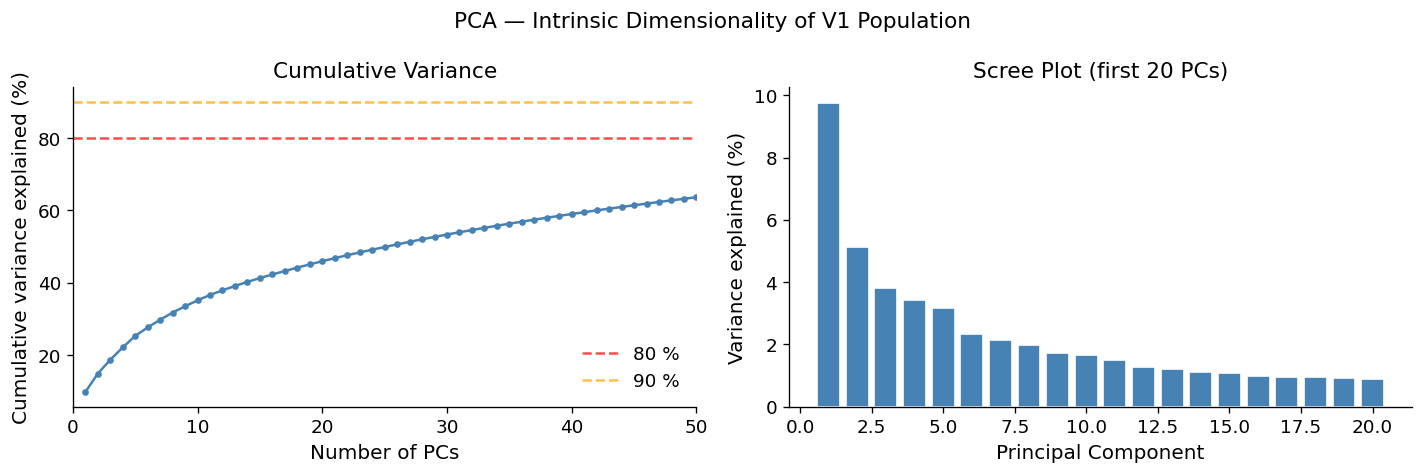

PCs for 80 % variance : 51
PCs for 90 % variance : 51
Variance in PC1+PC2   : 14.9 %


In [11]:
# ── Fit PCA ───────────────────────────────────────────────────────────────────
n_pcs = min(50, R_scaled.shape[0]-1, R_scaled.shape[1]-1)
pca   = PCA(n_components=n_pcs, random_state=SEED)
R_pca = pca.fit_transform(R_scaled)

cumvar = np.cumsum(pca.explained_variance_ratio_)

# ── Scree + cumulative variance ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(np.arange(1, n_pcs+1), cumvar * 100, 'o-', markersize=3, color='steelblue')
axes[0].axhline(80, color='red',    linestyle='--', alpha=0.7, label='80 %')
axes[0].axhline(90, color='orange', linestyle='--', alpha=0.7, label='90 %')
axes[0].set_xlabel('Number of PCs'); axes[0].set_ylabel('Cumulative variance explained (%)')
axes[0].set_title('Cumulative Variance'); axes[0].legend(); axes[0].set_xlim(0, n_pcs)

axes[1].bar(np.arange(1, 21), pca.explained_variance_ratio_[:20] * 100,
            color='steelblue', edgecolor='white')
axes[1].set_xlabel('Principal Component'); axes[1].set_ylabel('Variance explained (%)')
axes[1].set_title('Scree Plot (first 20 PCs)')

plt.suptitle('PCA — Intrinsic Dimensionality of V1 Population', fontsize=13)
plt.tight_layout()
plt.savefig('fig_pca_variance.png', dpi=150); plt.show()

n80 = np.searchsorted(cumvar, 0.80) + 1
n90 = np.searchsorted(cumvar, 0.90) + 1
print(f"PCs for 80 % variance : {n80}")
print(f"PCs for 90 % variance : {n90}")
print(f"Variance in PC1+PC2   : {cumvar[1]*100:.1f} %")

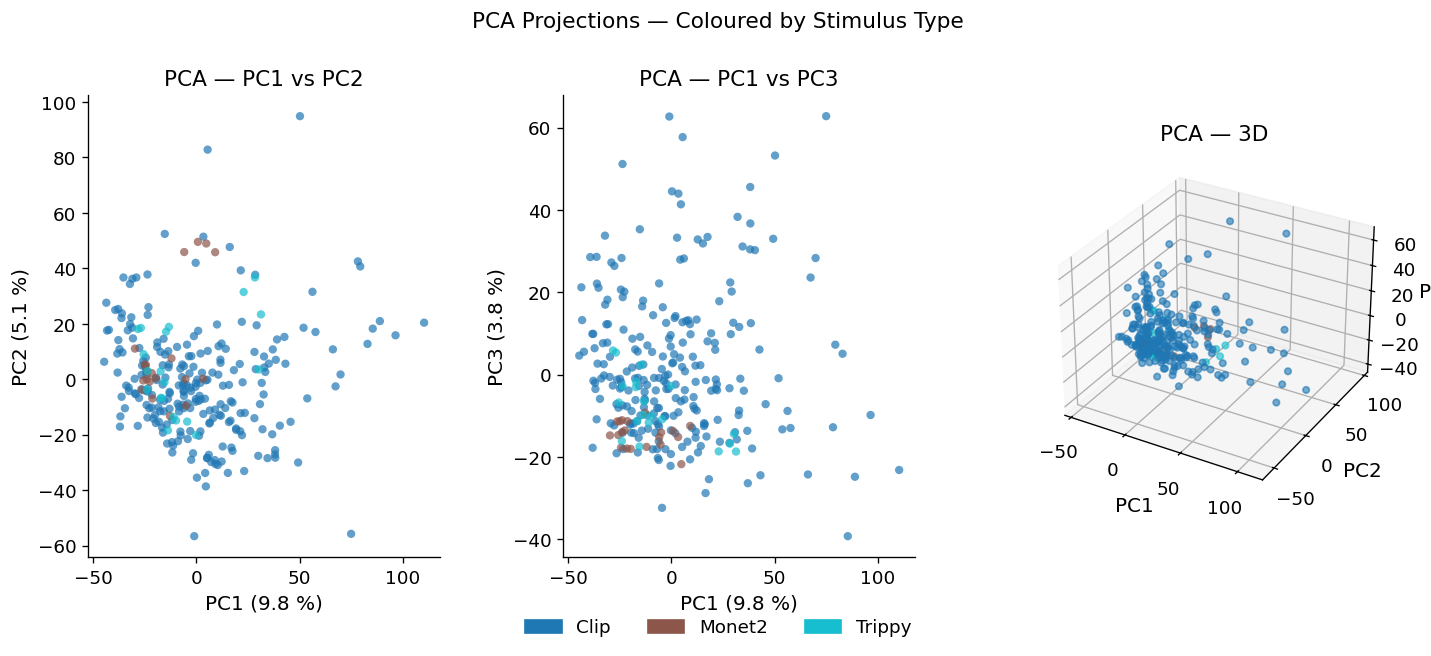

In [12]:
# ── PCA 2-D and 3-D scatter ───────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

# PC1 vs PC2
ax1 = fig.add_subplot(gs[0])
for lbl in unique_labels:
    m = labels == lbl
    ax1.scatter(R_pca[m,0], R_pca[m,1], color=label_to_color[lbl],
                alpha=0.7, s=25, edgecolors='none', label=lbl)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)')
ax1.set_title('PCA — PC1 vs PC2')

# PC1 vs PC3
ax2 = fig.add_subplot(gs[1])
for lbl in unique_labels:
    m = labels == lbl
    ax2.scatter(R_pca[m,0], R_pca[m,2], color=label_to_color[lbl],
                alpha=0.7, s=25, edgecolors='none')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)')
ax2.set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f} %)')
ax2.set_title('PCA — PC1 vs PC3')

# 3-D
ax3 = fig.add_subplot(gs[2], projection='3d')
for lbl in unique_labels:
    m = labels == lbl
    ax3.scatter(R_pca[m,0], R_pca[m,1], R_pca[m,2],
                color=label_to_color[lbl], alpha=0.6, s=15)
ax3.set_xlabel('PC1'); ax3.set_ylabel('PC2'); ax3.set_zlabel('PC3')
ax3.set_title('PCA — 3D')

fig.legend(handles=legend_patches, loc='lower center',
           ncol=n_types, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('PCA Projections — Coloured by Stimulus Type', fontsize=13, y=1.02)
plt.savefig('fig_pca_scatter.png', dpi=150); plt.show()

### 7b. t-SNE

t-SNE is a nonlinear method that preserves local neighbourhood structure.
It is sensitive to the **perplexity** hyperparameter (≈ effective neighbourhood
size).  We run three values to check robustness.  t-SNE is applied to the first
50 PCA components — this is standard practice and both speeds up computation
and denoises the input.

In [13]:
# ── t-SNE ─────────────────────────────────────────────────────────────────────
n_pca_for_tsne = min(50, n_pcs)
tsne_results   = {}
PERPLEXITIES   = [15, 30, 50]

print("Running t-SNE for three perplexity values...")
for perp in PERPLEXITIES:
    tsne = TSNE(n_components=2, perplexity=perp, random_state=SEED,
                max_iter=1000, learning_rate='auto', init='pca')
    tsne_results[perp] = tsne.fit_transform(R_pca[:, :n_pca_for_tsne])
    print(f"  perplexity={perp:3d}  ✓")

R_tsne = tsne_results[30]   # default for downstream analysis

Running t-SNE for three perplexity values...


  perplexity= 15  ✓


  perplexity= 30  ✓


  perplexity= 50  ✓


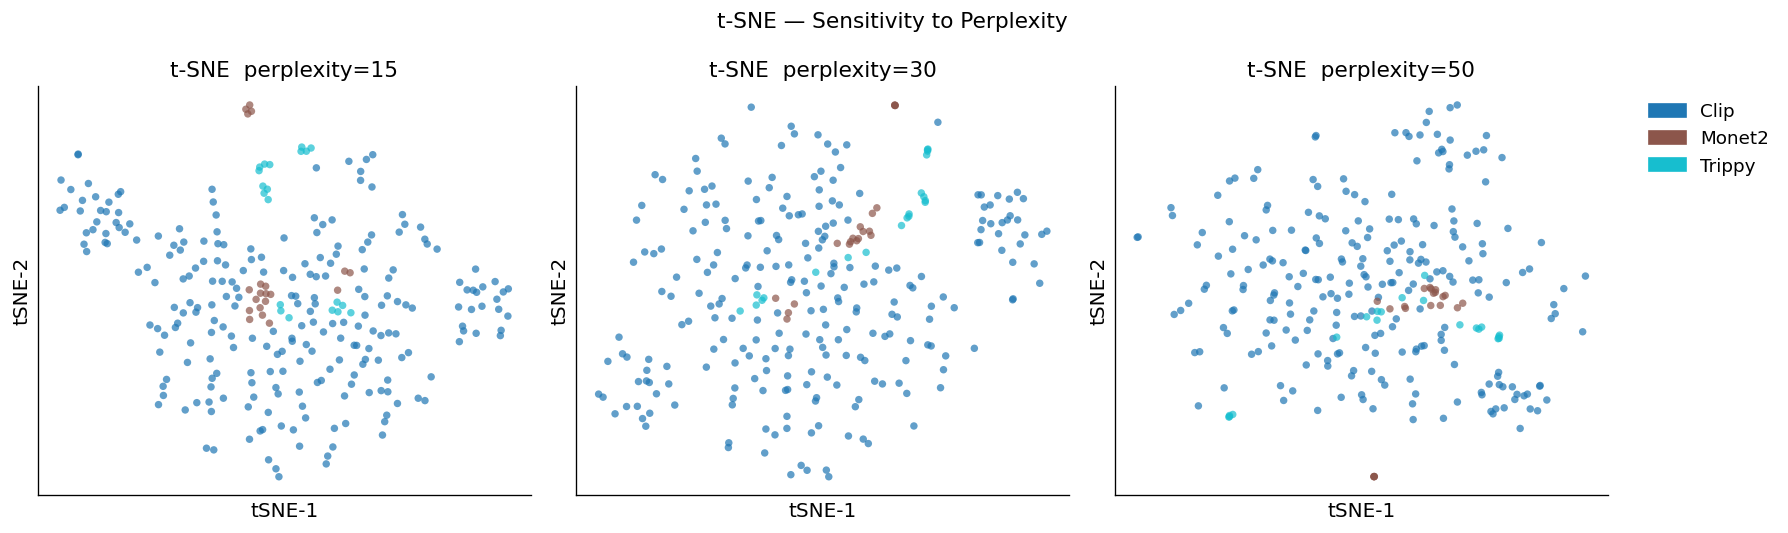

In [14]:
# ── t-SNE: perplexity comparison ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, perp in zip(axes, PERPLEXITIES):
    R_t = tsne_results[perp]
    for lbl in unique_labels:
        m = labels == lbl
        ax.scatter(R_t[m,0], R_t[m,1], color=label_to_color[lbl],
                   alpha=0.7, s=20, edgecolors='none')
    ax.set_title(f't-SNE  perplexity={perp}')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel('tSNE-1'); ax.set_ylabel('tSNE-2')

axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
plt.suptitle('t-SNE — Sensitivity to Perplexity', fontsize=13)
plt.tight_layout()
plt.savefig('fig_tsne_perplexity.png', dpi=150); plt.show()

### 7c. UMAP

UMAP (Uniform Manifold Approximation and Projection) is faster than t-SNE and
better preserves global structure alongside local neighbourhoods.  The key
hyperparameter is **n_neighbors** (local neighbourhood size) and **min_dist**
(minimum distance in the embedding).

Running UMAP for three n_neighbors values...


  n_neighbors=  5  ✓


  n_neighbors= 15  ✓


  n_neighbors= 50  ✓


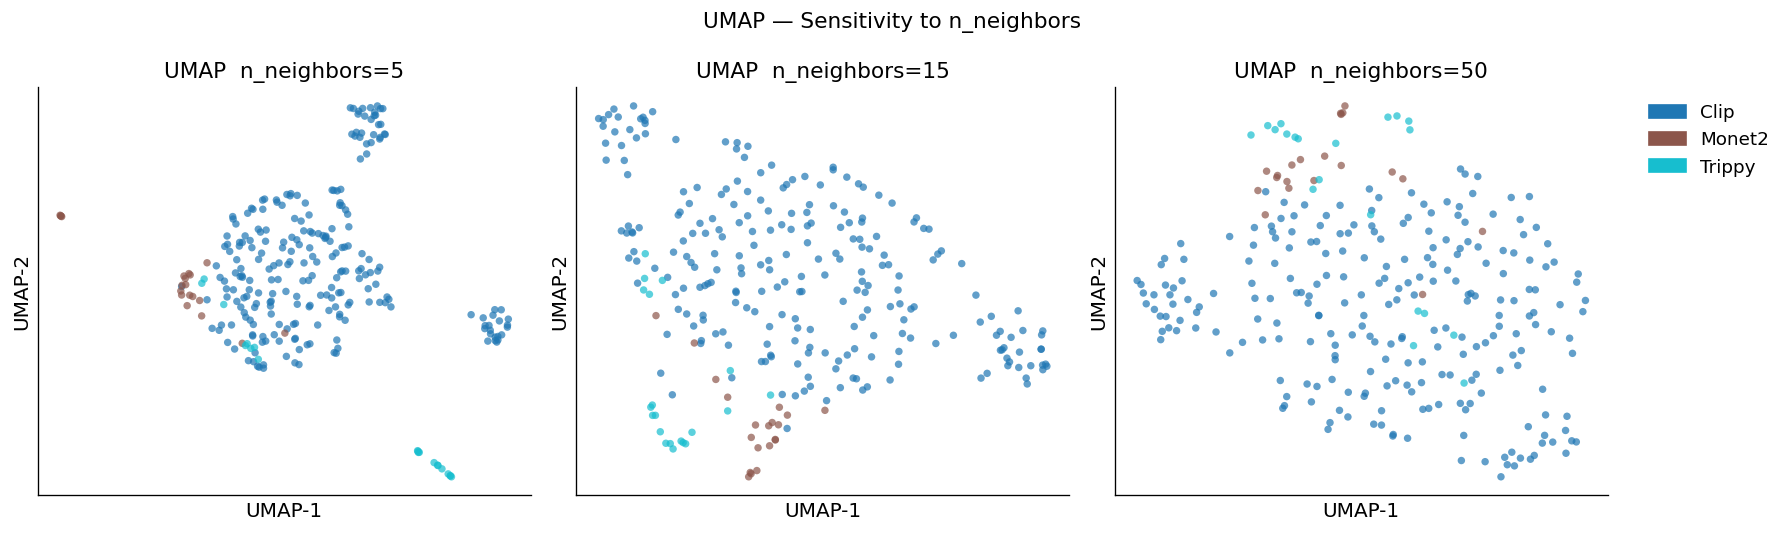

In [15]:
# ── UMAP ──────────────────────────────────────────────────────────────────────
if UMAP_AVAILABLE:
    umap_results = {}
    N_NEIGHBORS_LIST = [5, 15, 50]

    print("Running UMAP for three n_neighbors values...")
    for nn in N_NEIGHBORS_LIST:
        reducer = umap.UMAP(n_components=2, n_neighbors=nn,
                            min_dist=0.1, metric='euclidean',
                            random_state=SEED)
        umap_results[nn] = reducer.fit_transform(R_pca[:, :n_pca_for_tsne])
        print(f"  n_neighbors={nn:3d}  ✓")

    R_umap = umap_results[15]   # default

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, nn in zip(axes, N_NEIGHBORS_LIST):
        R_u = umap_results[nn]
        for lbl in unique_labels:
            m = labels == lbl
            ax.scatter(R_u[m,0], R_u[m,1], color=label_to_color[lbl],
                       alpha=0.7, s=20, edgecolors='none')
        ax.set_title(f'UMAP  n_neighbors={nn}')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
    plt.suptitle('UMAP — Sensitivity to n_neighbors', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig_umap_neighbors.png', dpi=150); plt.show()

else:
    R_umap = None
    print("UMAP not installed — skipping.  pip install umap-learn")

### 7d. CEBRA (Optional)

CEBRA is a contrastive-learning method designed specifically for neural data.
Unlike the unsupervised methods above, it is *self-supervised*: it uses
stimulus labels to guide the embedding, so it tends to produce the cleanest
separations.  Install with `pip install cebra`.

  0%|          | 0/2000 [00:00<?, ?it/s]

pos: -0.5525 neg:  5.3397 total:  4.7872 temperature:  1.0000:   0%|          | 0/2000 [00:00<?, ?it/s]

pos: -0.5525 neg:  5.3397 total:  4.7872 temperature:  1.0000:   0%|          | 1/2000 [00:00<14:23,  2.32it/s]

pos: -0.3688 neg:  5.3150 total:  4.9462 temperature:  1.0000:   0%|          | 1/2000 [00:00<14:23,  2.32it/s]

pos: -0.3688 neg:  5.3150 total:  4.9462 temperature:  1.0000:   0%|          | 2/2000 [00:00<08:04,  4.12it/s]

...

pos: -0.5551 neg:  5.2868 total:  4.7317 temperature:  1.0000: 100%|█████████▉| 1998/2000 [03:14<00:00, 10.53it/s]

pos: -0.5605 neg:  5.2921 total:  4.7315 temperature:  1.0000: 100%|█████████▉| 1998/2000 [03:14<00:00, 10.53it/s]

pos: -0.5408 neg:  5.2742 total:  4.7334 temperature:  1.0000: 100%|█████████▉| 1998/2000 [03:14<00:00, 10.53it/s]

pos: -0.5408 neg:  5.2742 total:  4.7334 temperature:  1.0000: 100%|██████████| 2000/2000 [03:14<00:00, 10.53it/s]

pos: -0.5408 neg:  5.2742 total:  4.7334 temperature:  1.0000: 100%|██████████| 2000/2000 [03:14<00:00, 10.30it/s]

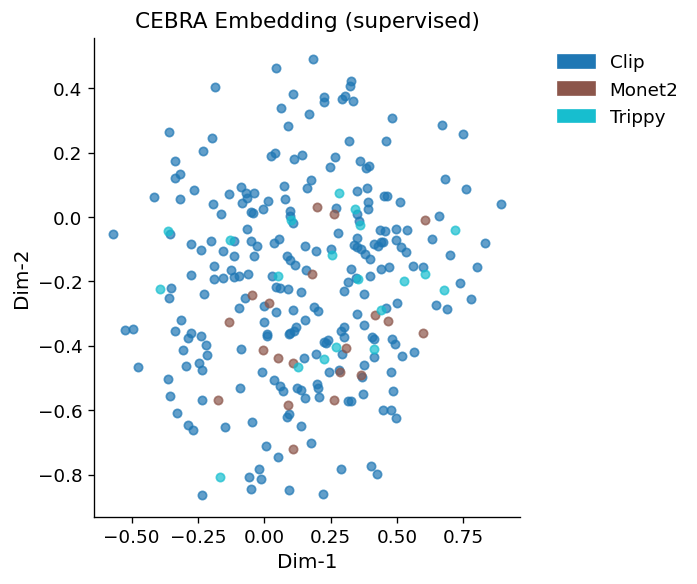

In [16]:
# ── CEBRA (optional) ─────────────────────────────────────────────────────────
if CEBRA_AVAILABLE:
    import torch
    label_cont = y.astype(np.float32).reshape(-1, 1)

    cb_model = cebra.CEBRA(
        model_architecture='offset10-model',
        batch_size=min(512, len(R_scaled)//2),
        learning_rate=3e-4,
        temperature=1.0,
        output_dimension=8,
        max_iterations=2000,
        device='cpu',
        verbose=True,
    )
    cb_model.fit(R_scaled.astype(np.float32), label_cont)
    R_cebra = cb_model.transform(R_scaled.astype(np.float32))

    fig, ax = plt.subplots(figsize=(6,5))
    for lbl in unique_labels:
        m = labels == lbl
        ax.scatter(R_cebra[m,0], R_cebra[m,1], color=label_to_color[lbl],
                   alpha=0.7, s=25, label=lbl)
    ax.set_title('CEBRA Embedding (supervised)'); ax.set_xlabel('Dim-1'); ax.set_ylabel('Dim-2')
    ax.legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
    plt.tight_layout()
    plt.savefig('fig_cebra.png', dpi=150); plt.show()
else:
    R_cebra = None
    print("CEBRA not available.  pip install cebra")

## 8. Side-by-Side Comparison of All Methods

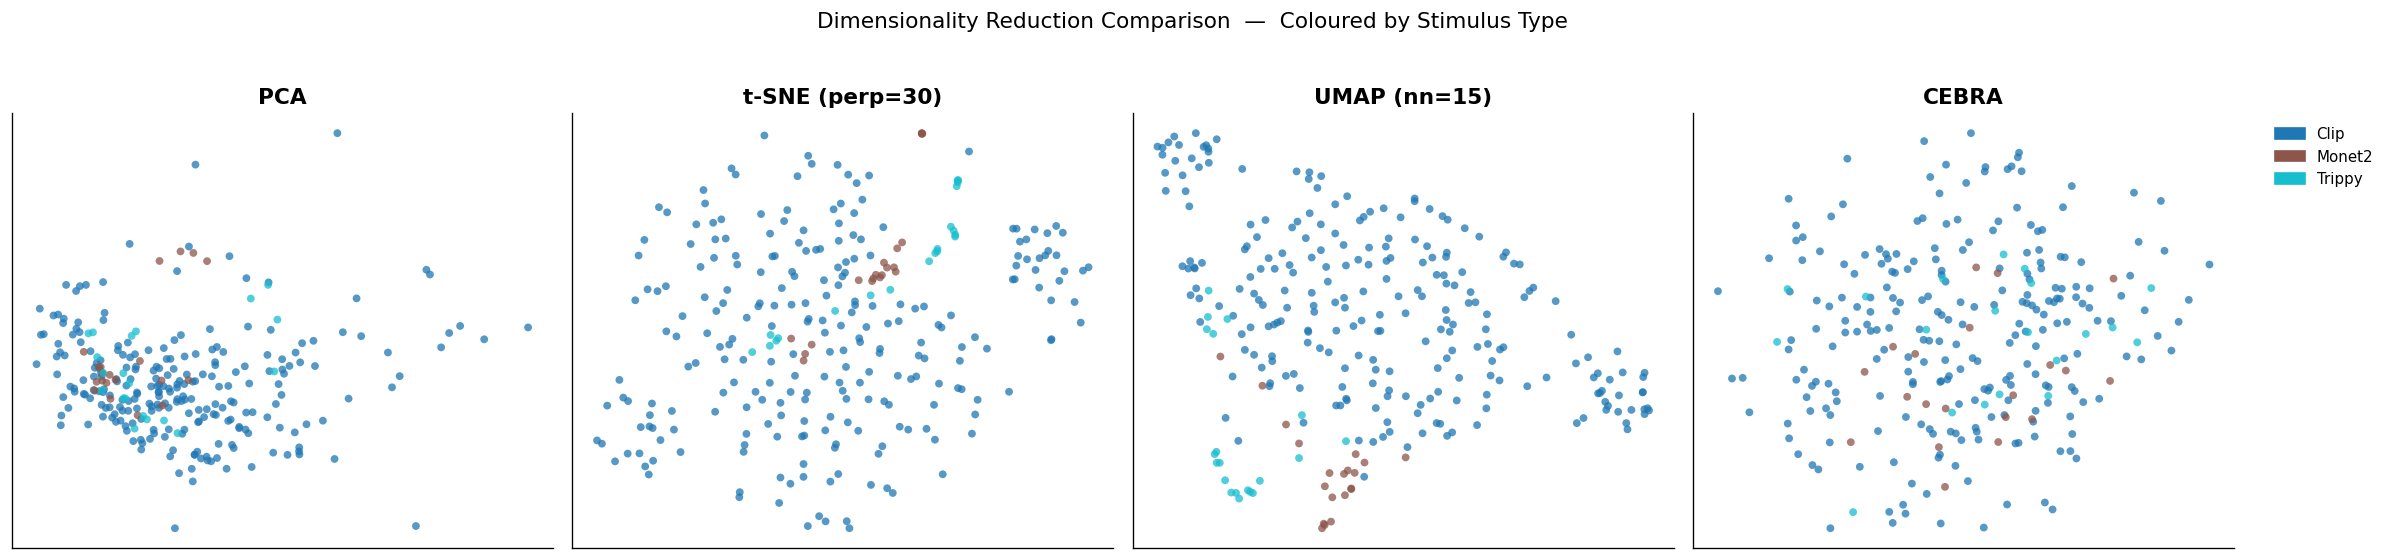

In [17]:
# ── Build list of available embeddings ───────────────────────────────────────
methods = [('PCA', R_pca[:, :2]), ('t-SNE (perp=30)', R_tsne)]
if UMAP_AVAILABLE  and R_umap  is not None: methods.append(('UMAP (nn=15)', R_umap))
if CEBRA_AVAILABLE and R_cebra is not None: methods.append(('CEBRA',         R_cebra[:, :2]))

n_m  = len(methods)
fig, axes = plt.subplots(1, n_m, figsize=(5 * n_m, 4.5))
if n_m == 1: axes = [axes]

for ax, (name, emb) in zip(axes, methods):
    for lbl in unique_labels:
        m = labels == lbl
        ax.scatter(emb[m,0], emb[m,1], color=label_to_color[lbl],
                   alpha=0.75, s=22, edgecolors='none')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1),
                loc='upper left', fontsize=9)
plt.suptitle('Dimensionality Reduction Comparison  —  Coloured by Stimulus Type',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('fig_dr_comparison.png', dpi=150); plt.show()

## 9. Quantitative Analysis

Visual scatter plots are informative but subjective.  We use two complementary
quantitative metrics:

* **Silhouette score** — how well each point fits its own cluster vs the
  nearest other cluster.  Range [−1, +1]; higher is more separated.
* **Cross-validated classifier accuracy** — a logistic regression trained on
  the embedding.  Significantly above chance indicates decodable structure.

In [18]:
# ── Silhouette scores ────────────────────────────────────────────────────────
sil_scores = {}

for name, emb in methods:
    sil_scores[name] = silhouette_score(emb, y)

# Also score the full high-dimensional data and several PCA depths
for k in [2, 5, 10, 20]:
    if k < R_pca.shape[1]:
        sil_scores[f'PCA-{k}D'] = silhouette_score(R_pca[:, :k], y)
sil_scores['Full data'] = silhouette_score(R_scaled, y)

print("Silhouette scores  (higher = better separated)")
print("─" * 40)
for name, sc in sorted(sil_scores.items(), key=lambda x: -x[1]):
    bar = '█' * max(0, int((sc + 1) * 20))
    print(f"  {name:20s}  {sc:+.4f}  {bar}")

Silhouette scores  (higher = better separated)
────────────────────────────────────────
  UMAP (nn=15)          +0.0962  █████████████████████
  t-SNE (perp=30)       -0.0790  ██████████████████
  PCA-20D               -0.0850  ██████████████████
  PCA-10D               -0.0872  ██████████████████
  PCA-5D                -0.0877  ██████████████████
  Full data             -0.1187  █████████████████
  CEBRA                 -0.1292  █████████████████
  PCA                   -0.1312  █████████████████
  PCA-2D                -0.1312  █████████████████


In [19]:
# ── Classifier accuracy ─────────────────────────────────────────────────────
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
clf = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED)

clf_scores = {}
for name, emb in methods:
    acc = cross_val_score(clf, emb, y, cv=cv, scoring='accuracy').mean()
    clf_scores[name] = acc

print(f"Classifier accuracy  (chance = {chance_level:.3f})")
print("─" * 40)
for name, acc in sorted(clf_scores.items(), key=lambda x: -x[1]):
    print(f"  {name:20s}  {acc:.4f}")

Classifier accuracy  (chance = 0.333)
────────────────────────────────────────
  UMAP (nn=15)          0.9393
  PCA                   0.8571
  t-SNE (perp=30)       0.8571
  CEBRA                 0.8571


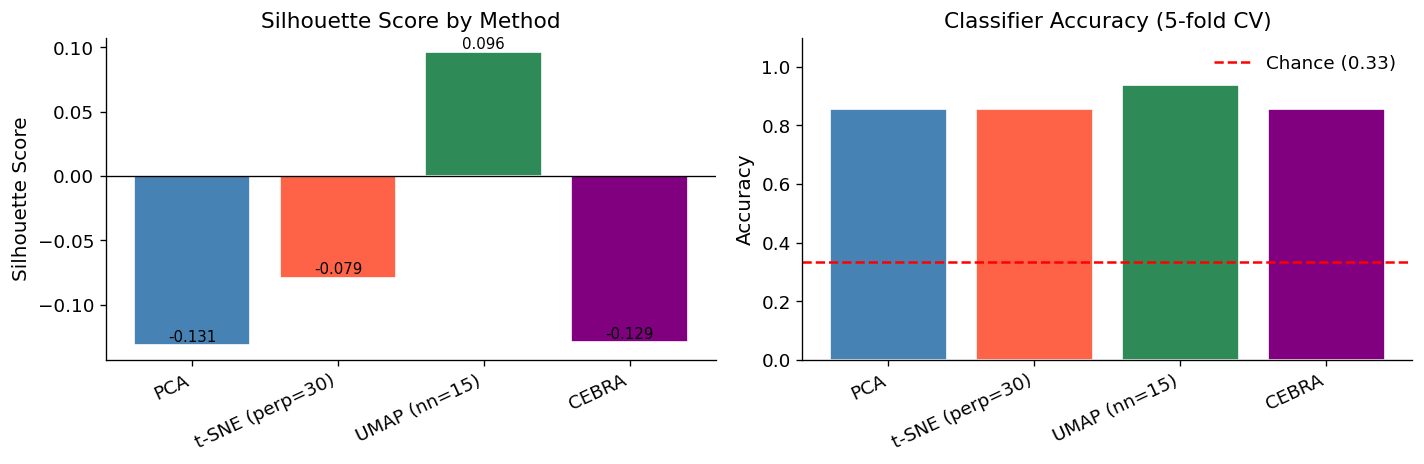

In [20]:
# ── Summary bar charts ───────────────────────────────────────────────────────
# Keep only the main 2D embeddings for plotting clarity
plot_names = [m[0] for m in methods]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Silhouette
sil_vals = [sil_scores.get(n, np.nan) for n in plot_names]
bars = axes[0].bar(plot_names, sil_vals,
                   color=['steelblue','tomato','seagreen','purple'][:len(plot_names)],
                   edgecolor='white')
axes[0].axhline(0, color='k', linewidth=0.8)
axes[0].set_title('Silhouette Score by Method'); axes[0].set_ylabel('Silhouette Score')
axes[0].set_xticklabels(plot_names, rotation=25, ha='right')
for bar, v in zip(bars, sil_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003, f'{v:.3f}', ha='center', fontsize=9)

# Classifier
clf_vals = [clf_scores.get(n, np.nan) for n in plot_names]
axes[1].bar(plot_names, clf_vals,
            color=['steelblue','tomato','seagreen','purple'][:len(plot_names)],
            edgecolor='white')
axes[1].axhline(chance_level, color='red', linestyle='--',
                label=f'Chance ({chance_level:.2f})')
axes[1].set_title('Classifier Accuracy (5-fold CV)')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticklabels(plot_names, rotation=25, ha='right')
axes[1].set_ylim(0, 1.1); axes[1].legend()

plt.tight_layout()
plt.savefig('fig_quantitative.png', dpi=150); plt.show()

## 10. Shuffle Control

To confirm that the separability we observe is genuinely driven by stimulus
identity (and not by noise, chance correlations, or overfitting), we repeat
the silhouette and classifier evaluation 100 times with **randomly permuted
labels**.  The real values should lie far in the tail of the null distribution,
and we report p-values from a one-sample t-test.

Running 100 shuffle controls ...


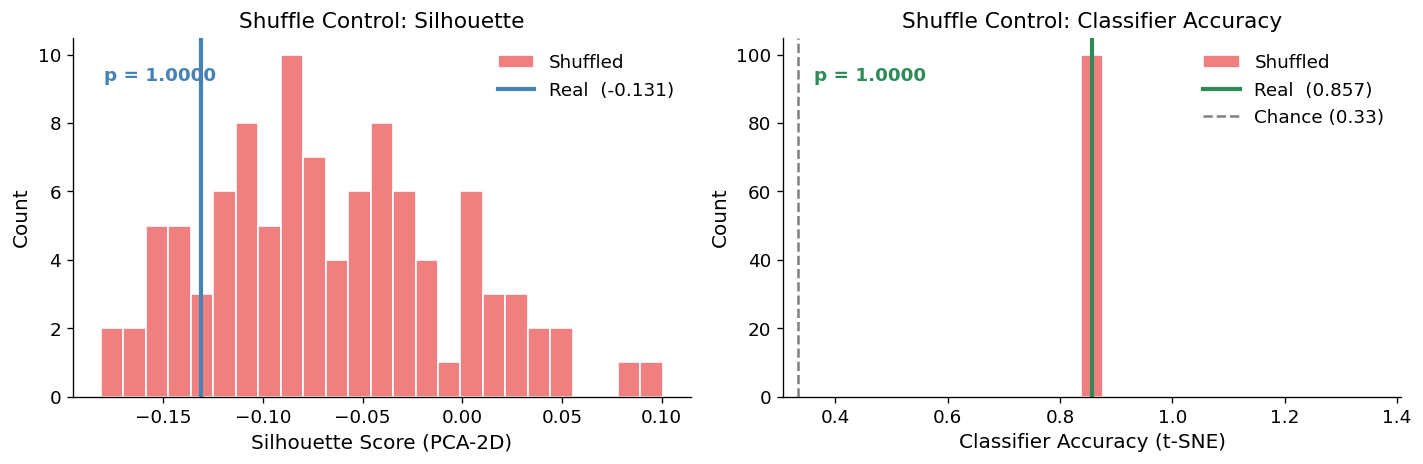


Silhouette  — real: -0.1312  |  null: -0.0660 ± 0.0608  |  p=1.0000
Accuracy    — real: 0.8571  |  null: 0.8571 ± 0.0000  |  p=1.0000


In [21]:
# ── Shuffle control (100 permutations) ───────────────────────────────────────
N_SHUFFLES = 100
rng = np.random.default_rng(seed=SEED)

null_sil_pca  = []
null_acc_tsne = []

print(f"Running {N_SHUFFLES} shuffle controls ...")
for _ in range(N_SHUFFLES):
    y_s = rng.permutation(y)
    null_sil_pca.append( silhouette_score(R_pca[:, :2], y_s) )
    null_acc_tsne.append( cross_val_score(clf, R_tsne, y_s, cv=cv,
                                          scoring='accuracy').mean() )

null_sil_pca  = np.array(null_sil_pca)
null_acc_tsne = np.array(null_acc_tsne)

real_sil  = sil_scores.get('PCA', sil_scores.get('PCA-2D',
            silhouette_score(R_pca[:, :2], y)))
real_acc  = clf_scores.get('t-SNE (perp=30)',
            cross_val_score(clf, R_tsne, y, cv=cv, scoring='accuracy').mean())

_, p_sil = ttest_1samp(null_sil_pca,  real_sil,  alternative='less')
_, p_acc = ttest_1samp(null_acc_tsne, real_acc, alternative='less')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(null_sil_pca, bins=25, color='lightcoral', edgecolor='white', label='Shuffled')
axes[0].axvline(real_sil, color='steelblue', lw=2.5, label=f'Real  ({real_sil:.3f})')
axes[0].set_xlabel('Silhouette Score (PCA-2D)'); axes[0].set_ylabel('Count')
axes[0].set_title('Shuffle Control: Silhouette'); axes[0].legend()
axes[0].text(0.05, 0.92, f'p = {p_sil:.4f}', transform=axes[0].transAxes,
             color='steelblue', fontweight='bold', va='top')

axes[1].hist(null_acc_tsne, bins=25, color='lightcoral', edgecolor='white', label='Shuffled')
axes[1].axvline(real_acc,  color='seagreen', lw=2.5, label=f'Real  ({real_acc:.3f})')
axes[1].axvline(chance_level, color='gray', lw=1.5, linestyle='--',
                label=f'Chance ({chance_level:.2f})')
axes[1].set_xlabel('Classifier Accuracy (t-SNE)'); axes[1].set_ylabel('Count')
axes[1].set_title('Shuffle Control: Classifier Accuracy'); axes[1].legend()
axes[1].text(0.05, 0.92, f'p = {p_acc:.4f}', transform=axes[1].transAxes,
             color='seagreen', fontweight='bold', va='top')

plt.tight_layout()
plt.savefig('fig_shuffle_control.png', dpi=150); plt.show()

print(f"\nSilhouette  — real: {real_sil:.4f}  |  null: {null_sil_pca.mean():.4f} ± {null_sil_pca.std():.4f}  |  p={p_sil:.4f}")
print(f"Accuracy    — real: {real_acc:.4f}  |  null: {null_acc_tsne.mean():.4f} ± {null_acc_tsne.std():.4f}  |  p={p_acc:.4f}")

## 11. Movie Clip Temporal Analysis

For naturalistic movie clips we ask whether **temporally adjacent frames**
cluster nearby in the neural embedding.  If the manifold is smooth, the neural
state should trace a continuous trajectory through stimulus space — frames
that are close in time should look similar to the population.

We build a frame-level response matrix (one row per frame, not per trial) for
trials of the movie-clip stimulus type, then apply PCA and t-SNE and colour
points by their time index within the clip.

In [22]:
# ── Identify movie-clip trials ────────────────────────────────────────────────
movie_keywords = ['clip', 'movie', 'natural', 'film']
movie_types = [l for l in unique_labels
               if any(kw in l.lower() for kw in movie_keywords)]

if not movie_types:
    # Fall back: use the two most populous stimulus types
    movie_types = [c for c, _ in Counter(labels).most_common(2)]
    print(f"No explicit movie labels — using: {movie_types}")
else:
    print(f"Movie-like labels found: {movie_types}")

Movie-like labels found: [np.str_('Clip')]


Building frame-level response matrix ...


Frame matrix: (5760, 7855)   (240 unique clips)


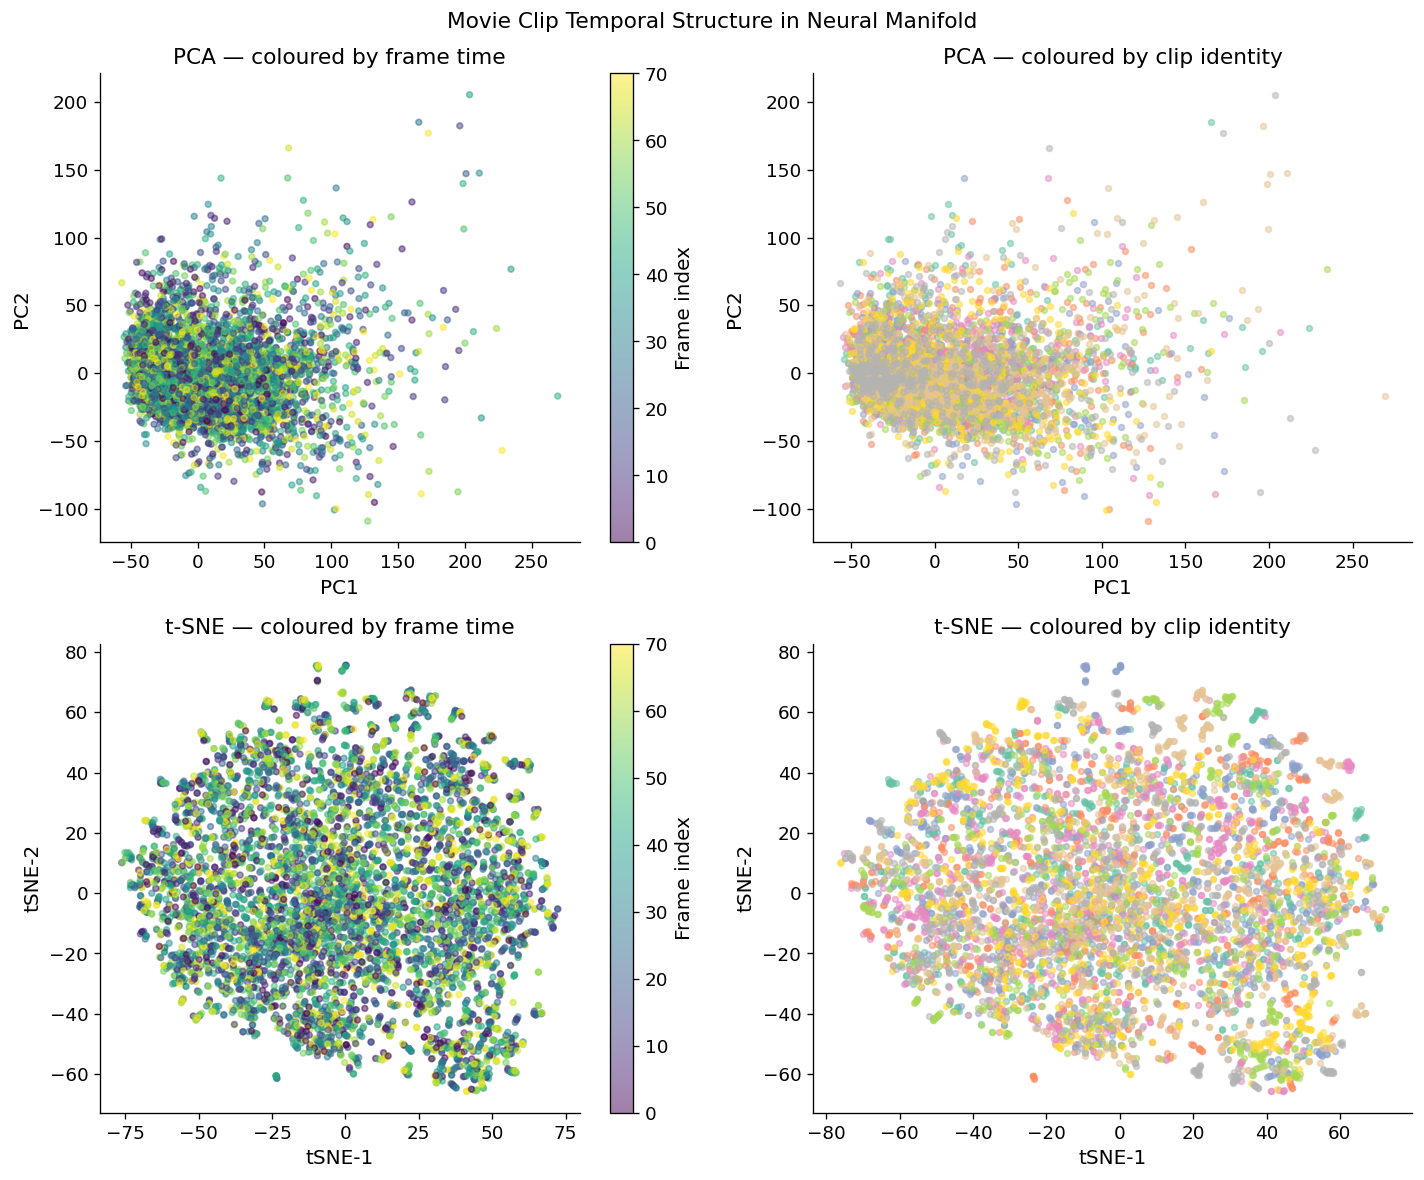

In [23]:
# ── Frame-level response matrix ──────────────────────────────────────────────
frame_resp   = []
frame_time   = []   # frame index within clip
frame_hash   = []   # unique clip identity
STEP = 5            # take every 5th frame (trade-off: coverage vs speed)

print("Building frame-level response matrix ...")

for trial_idx, h in enumerate(hashes):
    if funcreader.get_video_type(h) not in movie_types:
        continue
    try:
        r = funcreader.get_trial(SESSION, trial_idx)
        if r is None or 'responses' not in r:
            continue
        n_frames = r['responses'].shape[1]
        for f in range(0, n_frames, STEP):
            frame_resp.append(r['responses'][:, f])
            frame_time.append(f)
            frame_hash.append(h)
    except Exception:
        continue

if not frame_resp:
    print("No movie-clip trials found — skipping this section.")
else:
    RF         = np.array(frame_resp)
    frame_time = np.array(frame_time)
    frame_hash = np.array(frame_hash)

    # Preprocess identically to R_matrix
    RF_clean   = np.nan_to_num(RF[:, keep_neurons], nan=0.0)
    RF_scaled  = scaler.transform(RF_clean)

    RF_pca = pca.transform(RF_scaled)
    print(f"Frame matrix: {RF_scaled.shape}   ({len(np.unique(frame_hash))} unique clips)")

    # t-SNE on frames
    tsne_fr = TSNE(n_components=2, perplexity=20, random_state=SEED,
                   max_iter=1000, learning_rate='auto', init='pca')
    RF_tsne = tsne_fr.fit_transform(RF_pca[:, :n_pca_for_tsne])

    # ── Plot: colour by time ───────────────────────────────────────────────
    unique_clips = np.unique(frame_hash)
    clip_cmap    = plt.cm.get_cmap('Set2', len(unique_clips))
    hash_to_col  = {h: clip_cmap(i) for i, h in enumerate(unique_clips)}

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # PCA — coloured by frame time
    sc = axes[0,0].scatter(RF_pca[:,0], RF_pca[:,1],
                           c=frame_time, cmap='viridis', alpha=0.5, s=12)
    plt.colorbar(sc, ax=axes[0,0], label='Frame index')
    axes[0,0].set_title('PCA — coloured by frame time')
    axes[0,0].set_xlabel('PC1'); axes[0,0].set_ylabel('PC2')

    # PCA — coloured by clip identity
    for h in unique_clips:
        m = frame_hash == h
        axes[0,1].scatter(RF_pca[m,0], RF_pca[m,1],
                          color=hash_to_col[h], alpha=0.5, s=12)
    axes[0,1].set_title('PCA — coloured by clip identity')
    axes[0,1].set_xlabel('PC1'); axes[0,1].set_ylabel('PC2')

    # t-SNE — coloured by frame time
    sc2 = axes[1,0].scatter(RF_tsne[:,0], RF_tsne[:,1],
                            c=frame_time, cmap='viridis', alpha=0.5, s=12)
    plt.colorbar(sc2, ax=axes[1,0], label='Frame index')
    axes[1,0].set_title('t-SNE — coloured by frame time')
    axes[1,0].set_xlabel('tSNE-1'); axes[1,0].set_ylabel('tSNE-2')

    # t-SNE — coloured by clip identity
    for h in unique_clips:
        m = frame_hash == h
        axes[1,1].scatter(RF_tsne[m,0], RF_tsne[m,1],
                          color=hash_to_col[h], alpha=0.5, s=12)
    axes[1,1].set_title('t-SNE — coloured by clip identity')
    axes[1,1].set_xlabel('tSNE-1'); axes[1,1].set_ylabel('tSNE-2')

    plt.suptitle('Movie Clip Temporal Structure in Neural Manifold', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig_movie_temporal.png', dpi=150); plt.show()

## 12. Neuron-Space Analysis (Bonus)

Above we reduced **stimuli in neuron-space** (each row = one stimulus).  We
can also flip the matrix and reduce **neurons in stimulus-response space** (each
row = one neuron, columns = responses to each stimulus).  This lets us ask
whether neurons with similar functional properties — same layer, same cell type
— cluster together.

Neuron-space matrix: (7855, 280)


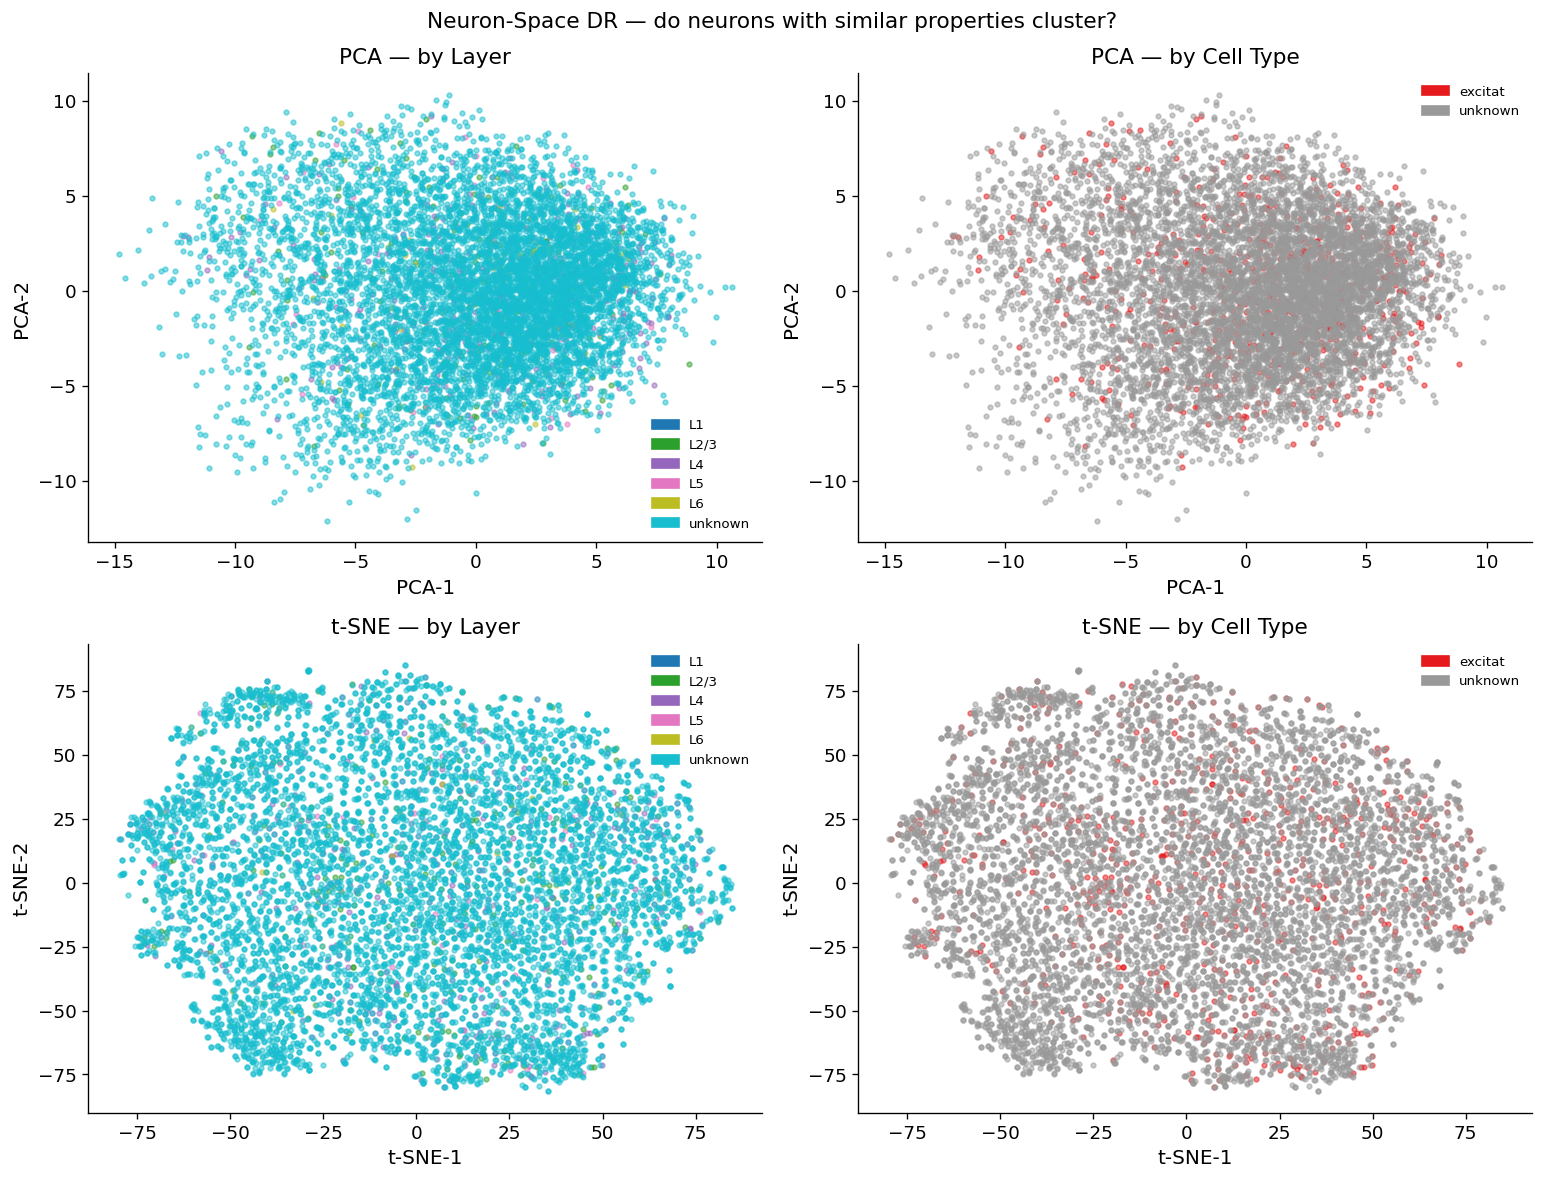

In [24]:
# ── Neuron-space DR ───────────────────────────────────────────────────────────
R_neuron = R_scaled.T          # (n_neurons, n_stimuli)
print(f"Neuron-space matrix: {R_neuron.shape}")

pca_n  = PCA(n_components=min(20, R_neuron.shape[1]-1), random_state=SEED)
RN_pca = pca_n.fit_transform(R_neuron)

tsne_n  = TSNE(n_components=2, perplexity=min(30, len(R_neuron)//5),
               random_state=SEED, learning_rate='auto', init='pca')
RN_tsne = tsne_n.fit_transform(RN_pca)

# ── Get layer / type metadata for kept neurons ────────────────────────────────
n_kept = R_neuron.shape[0]
n_meta = min(len(v1_neurons), n_kept)
meta   = v1_neurons.reset_index(drop=True).iloc[:n_meta]

# Pad to n_kept — neurons beyond the v1_neurons list are labelled 'unknown'
neuron_layer = np.array(['unknown'] * n_kept)
neuron_type  = np.array(['unknown'] * n_kept)
if 'layer' in meta.columns:
    neuron_layer[:n_meta] = meta['layer'].fillna('unknown').values
if 'classification_system' in meta.columns:
    neuron_type[:n_meta]  = meta['classification_system'].fillna('unknown').values

# ── Plot by layer ──────────────────────────────────────────────────────────
LAYERS = [l for l in ['L1','L2/3','L4','L5','L6','unknown'] if l in neuron_layer]
lyr_cmap  = plt.cm.get_cmap('tab10', len(LAYERS))
lyr_color = {l: lyr_cmap(i) for i, l in enumerate(LAYERS)}
lyr_patches = [Patch(color=lyr_color[l], label=l) for l in LAYERS]

# ── Plot by cell type ──────────────────────────────────────────────────────
TYPES = np.unique(neuron_type)
typ_cmap  = plt.cm.get_cmap('Set1', len(TYPES))
typ_color = {t: typ_cmap(i) for i, t in enumerate(TYPES)}
typ_patches = [Patch(color=typ_color[t], label=t) for t in TYPES]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for row, (embedname, emb) in enumerate([('PCA', RN_pca[:,:2]), ('t-SNE', RN_tsne)]):
    # Layer
    for lyr in LAYERS:
        m = neuron_layer == lyr
        axes[row,0].scatter(emb[m,0], emb[m,1], color=lyr_color[lyr],
                            alpha=0.5, s=8)
    axes[row,0].set_title(f'{embedname} — by Layer')
    axes[row,0].set_xlabel(f'{embedname}-1'); axes[row,0].set_ylabel(f'{embedname}-2')
    axes[row,0].legend(handles=lyr_patches, markerscale=3, fontsize=8)

    # Cell type
    for t in TYPES:
        m = neuron_type == t
        axes[row,1].scatter(emb[m,0], emb[m,1], color=typ_color[t],
                            alpha=0.5, s=8)
    axes[row,1].set_title(f'{embedname} — by Cell Type')
    axes[row,1].set_xlabel(f'{embedname}-1'); axes[row,1].set_ylabel(f'{embedname}-2')
    axes[row,1].legend(handles=typ_patches, markerscale=3, fontsize=8)

plt.suptitle('Neuron-Space DR — do neurons with similar properties cluster?',
             fontsize=13)
plt.tight_layout()
plt.savefig('fig_neuron_space.png', dpi=150); plt.show()

## 13. Results Summary

In [25]:
# ── Summary table ────────────────────────────────────────────────────────────
summary_rows = []
for name, emb in methods:
    sil = silhouette_score(emb, y)
    acc = cross_val_score(clf, emb, y, cv=cv, scoring='accuracy').mean()
    summary_rows.append({
        'Method'               : name,
        'Dimensions'           : emb.shape[1],
        'Silhouette score'     : f'{sil:.4f}',
        'Classifier accuracy'  : f'{acc:.4f}',
        'Chance level'         : f'{chance_level:.4f}',
    })

summary_df = pd.DataFrame(summary_rows)
print("\n══ Results Summary ════════════════════════════════")
print(summary_df.to_string(index=False))

print(f"\nIntrinsic dimensionality (PCA):")
print(f"  PCs for 80 % variance : {n80}")
print(f"  PCs for 90 % variance : {n90}")
print(f"  Variance in PC1+PC2   : {cumvar[1]*100:.1f} %")


══ Results Summary ════════════════════════════════
         Method  Dimensions Silhouette score Classifier accuracy Chance level
            PCA           2          -0.1312              0.8571       0.3333
t-SNE (perp=30)           2          -0.0790              0.8571       0.3333
   UMAP (nn=15)           2           0.0962              0.9393       0.3333
          CEBRA           2          -0.1292              0.8571       0.3333

Intrinsic dimensionality (PCA):
  PCs for 80 % variance : 51
  PCs for 90 % variance : 51
  Variance in PC1+PC2   : 14.9 %


## 14. Discussion

### Addressing the Research Questions

**Q1 — Stimulus discriminability**  
If the silhouette scores are significantly positive (validated by the shuffle
control, p < 0.05) and classifier accuracy is well above chance, this confirms
that different visual stimuli occupy *distinct regions* of the neural manifold.
This is consistent with the view that V1 population activity encodes stimulus
identity in a decodable, geometrically structured way.

**Q2 — Algorithm agreement**  
PCA provides a linear baseline.  If t-SNE and UMAP reveal additional structure
(higher silhouette scores or classifier accuracy than PCA), this indicates
*nonlinear* organisation in the data — stimuli are not linearly separable in
the top PCs.  Conversely, if all methods agree, the structure is likely robust
and approximately linear.

**Q3 — Intrinsic dimensionality**  
A low number of PCs explaining most of the variance supports the neural
manifold hypothesis.  For example, if 10 PCs explain 80 % of variance across
hundreds of neurons, population activity is highly constrained.  This has
implications for theories of redundancy, noise correlations, and efficient
coding.

**Q4 — Temporal continuity in movie clips**  
If frames that are close in time cluster nearby in the embedding, the
neural manifold traces a smooth trajectory — the population "tracks" the visual
world continuously.  Jumps in the trajectory could correspond to scene cuts or
abrupt motion.

---

### Limitations

| Limitation | Impact |
|---|---|
| Single session (9_4) | May not generalise across animals or sessions |
| Frame-averaging | Discards within-trial temporal dynamics |
| Neuron selection (V1, proofread only) | Potential selection bias |
| t-SNE / UMAP stochasticity | Some structure may reflect initialisation |
| Curse of dimensionality | With many neurons, Euclidean distances compress; z-scoring and PCA pre-reduction mitigate this |
| NaN imputation | Neurons with missing data imputed with mean — could inflate or deflate structure |

---

### Possible Extensions

* **Multi-area comparison** — apply the same pipeline to V2, AL, PM and compare
  manifold geometries across the visual hierarchy.
* **Behavioural covariates** — use CEBRA with running speed or pupil dilation as
  auxiliary labels to disentangle sensory from motor signals.
* **Temporal dynamics** — instead of mean responses, use single-frame or
  sliding-window responses to study how the manifold evolves in time.
* **Session variability** — repeat the analysis across sessions (see Project 15)
  to assess reproducibility of the low-dimensional structure.
* **Structural comparison** — check whether the principal axes of the functional
  manifold align with structural features (layer, cell type, connectivity) from
  the EM reconstruction.

---

*Notebook generated for the MICrONS dataset analysis project.*  
*All figures are saved to the working directory for inclusion in the report.*